# Exercise 6 — Data Preprocessing and Analysis

This notebook explores environmental variables and species data from the EFIplus_medit dataset.

The main objectives are:
- Assess distribution of environmental variables
- Apply transformations when necessary
- Compute species richness
- Detect bivariate outliers
- Explore relationships across countries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("EFIplus_medit.csv", sep=";")

df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(38), int64(120), object(6)
memory usage: 6.3+ MB


In [6]:
df.describe()

,Latitude,Longitude,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,Calib_morphol,Calib_wqual,Geomorph1,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
count,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,4.615000e+03,...,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000
mean,41.660286,-4.220392,0.288964,0.790860,0.278388,0.811814,0.403313,0.460387,0.497306,4.550399e-12,...,0.000399,0.085412,0.000599,0.000399,0.012373,0.000200,0.196568,0.068250,0.132708,0.031132
std,1.654641,4.754419,0.453327,0.406735,0.448250,0.390900,0.490611,0.498478,0.500043,1.000108e+00,...,0.019976,0.279522,0.024463,0.019976,0.110554,0.014127,0.397442,0.252199,0.339293,0.173690
min,36.213984,-9.459453,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.465112e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.450919,-7.716600,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.129179e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,42.316060,-6.176062,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,4.515341e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,42.904789,-1.959129,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.319150e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,45.098423,15.625773,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.345204e-01,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
species_start = df.columns.get_loc("Abramis brama")
species_start

56

In [8]:
species_cols = df.columns[56:]
len(species_cols)

108

In [9]:
df["richness"] = df[species_cols].sum(axis=1)

df[["richness"]].head()

,richness
0,1
1,1
2,1
3,2
4,2


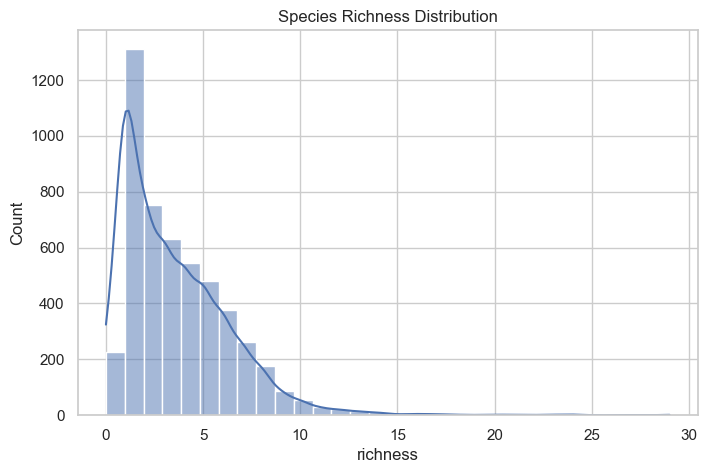

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["richness"], bins=30, kde=True)
plt.title("Species Richness Distribution")
plt.show()

### Species Richness

Species richness was calculated as the total number of species present at each sampling site by summing all species presence/absence columns, starting from *Abramis brama* onwards.

The distribution of species richness is strongly right-skewed, with most sites showing low numbers of species and a small number of sites exhibiting higher richness values.

This pattern is typical of ecological datasets, where only a few locations tend to support a large number of species.

In [11]:
env_vars = [
    "Altitude",
    "Actual_river_slope",
    "Elevation_mean_catch",
    "prec_ann_catch",
    "temp_ann",
    "temp_jan",
    "temp_jul"
]

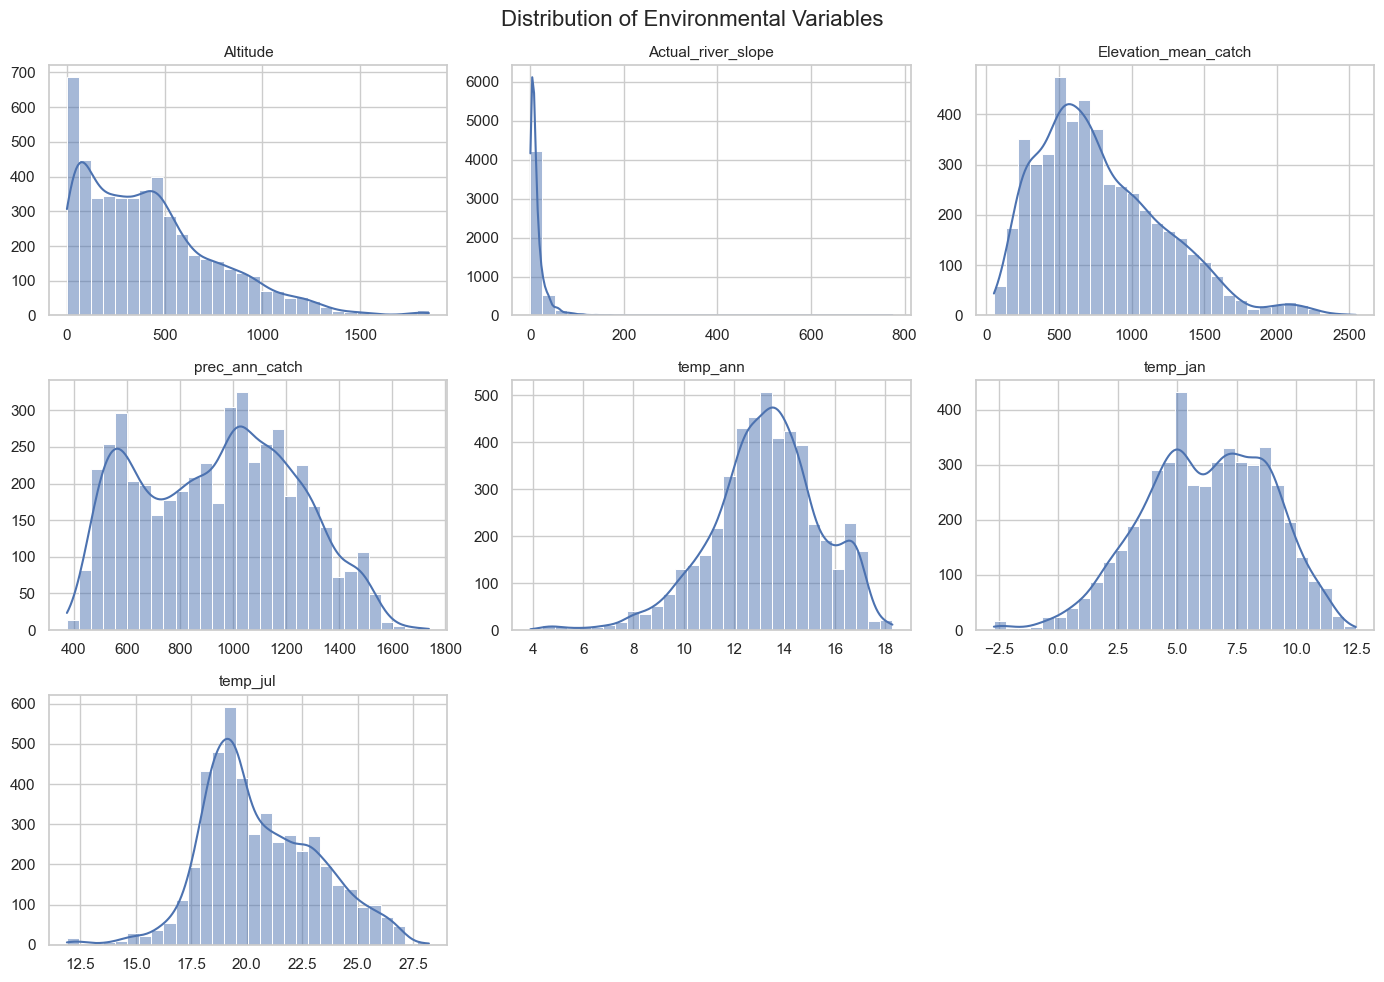

In [13]:
plt.figure(figsize=(14,10))

for i, var in enumerate(env_vars, 1):
    plt.subplot(3,3,i)
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(var, fontsize=11)
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle("Distribution of Environmental Variables", fontsize=16)
plt.tight_layout()
plt.show()

### Distribution of Environmental Variables

The distributions of the selected environmental variables were visually inspected using histograms.

Altitude and Actual river slope show clear right-skewed distributions, particularly slope, which exhibits a strong concentration of low values and a long tail. This suggests that transformation may be necessary before applying parametric analyses.

Elevation mean catch also presents some degree of right-skewness, although less pronounced.

Precipitation and temperature variables (annual and seasonal) appear approximately symmetric, with temperature variables showing distributions closer to normality.

Overall, transformations will be considered primarily for variables with strong skewness, namely slope and altitude.

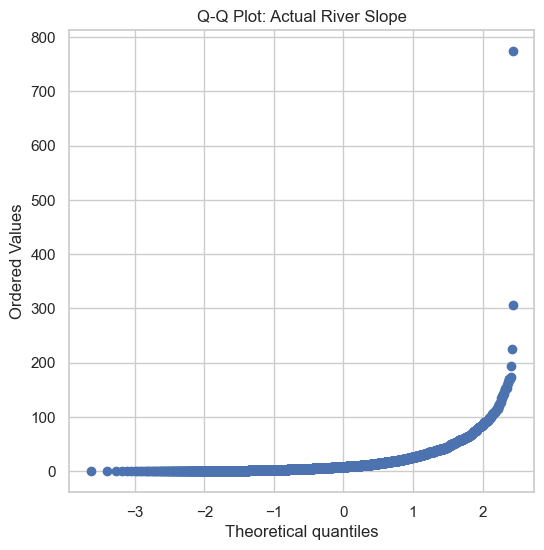

In [14]:
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(df["Actual_river_slope"], dist="norm", plot=plt)
plt.title("Q-Q Plot: Actual River Slope")
plt.show()

A Q-Q plot was used to further assess normality. The strong deviation from the reference line confirms that Actual river slope does not follow a normal distribution and would benefit from transformation.

In [15]:
df["log_slope"] = np.log1p(df["Actual_river_slope"])
df["log_altitude"] = np.log1p(df["Altitude"])

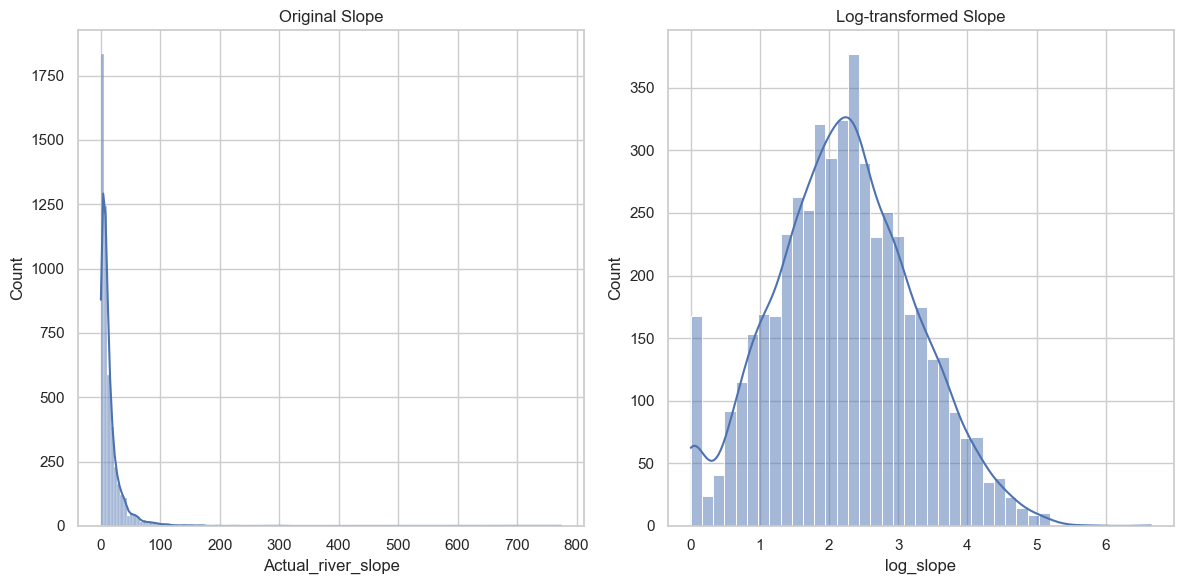

In [16]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(df["Actual_river_slope"], kde=True)
plt.title("Original Slope")

plt.subplot(1,2,2)
sns.histplot(df["log_slope"], kde=True)
plt.title("Log-transformed Slope")

plt.tight_layout()
plt.show()

### Data Transformation

Actual river slope showed a strong right-skewed distribution, with most observations concentrated near zero and a long tail of higher values.

To improve normality, a logarithmic transformation was applied using log(1 + x). This transformation reduces the influence of extreme values and compresses the scale of larger observations.

After transformation, the distribution appears much more symmetric and closer to a normal distribution, making it more suitable for parametric analyses.

In [17]:
df["log_altitude"] = np.log1p(df["Altitude"])

Altitude also showed moderate right-skewness and was log-transformed for consistency, although the effect was less pronounced than for slope.

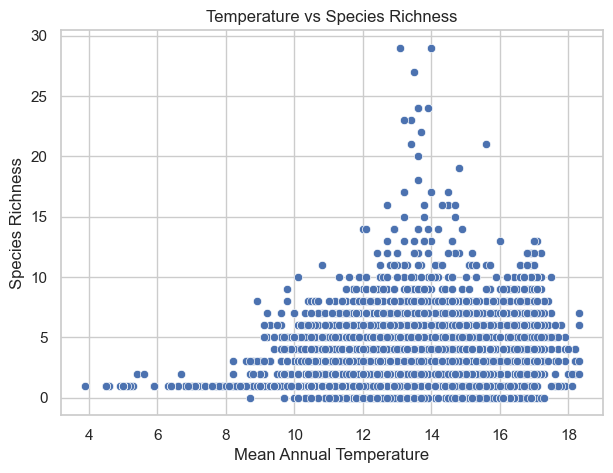

In [18]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["temp_ann"], y=df["richness"])
plt.xlabel("Mean Annual Temperature")
plt.ylabel("Species Richness")
plt.title("Temperature vs Species Richness")
plt.show()

### Relationship Between Temperature and Species Richness

The relationship between mean annual temperature and species richness was explored using a scatter plot.

A weak positive trend can be observed, with richness generally increasing with temperature. However, the relationship is not strongly linear.

Most observations are concentrated within a temperature range of approximately 10 to 17°C, with richness values typically below 10 species. A wider spread of richness values is observed at intermediate temperatures, suggesting greater variability in species composition under these conditions.

Some observations appear to deviate from the general pattern, indicating the possible presence of bivariate outliers.

In [19]:
X = df[["temp_ann", "richness"]]

In [20]:
iso = IsolationForest(contamination=0.02, random_state=42)
df["outlier"] = iso.fit_predict(X)

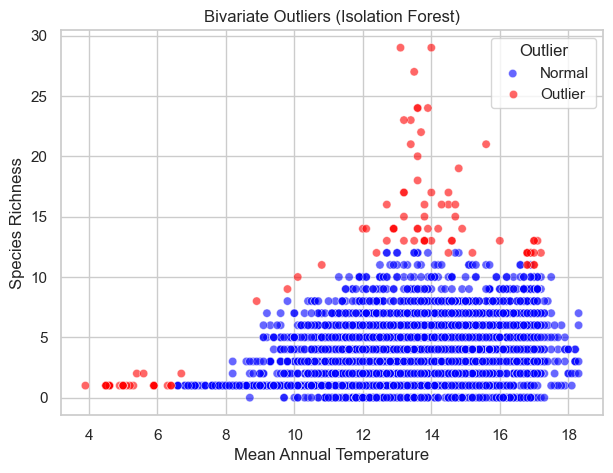

In [21]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["temp_ann"],
    y=df["richness"],
    hue=df["outlier"],
    palette={1: "blue", -1: "red"},
    alpha=0.6
)

plt.xlabel("Mean Annual Temperature")
plt.ylabel("Species Richness")
plt.title("Bivariate Outliers (Isolation Forest)")
plt.legend(title="Outlier", labels=["Normal", "Outlier"])

plt.show()

In [22]:
df["outlier"].value_counts()

outlier
 1    4910
-1     101
Name: count, dtype: int64

### Detection of Bivariate Outliers

To identify unusual combinations of temperature and species richness, a bivariate outlier detection method was applied using the Isolation Forest algorithm.

Isolation Forest is a machine learning approach that isolates observations based on how easily they can be separated from the rest of the data. Points that are more isolated are considered potential outliers.

A contamination rate of 2% was used, meaning that approximately 2% of the observations were expected to be outliers.

The results show that 101 observations were classified as outliers. These points tend to correspond to unusually high species richness values or uncommon combinations of temperature and richness.

The visualization highlights that most data points follow a consistent pattern, while outliers deviate clearly from this structure, particularly at higher richness values.

In [23]:
df["Country"].unique()

array(['Spain', 'France', 'Italy', 'Portugal'], dtype=object)

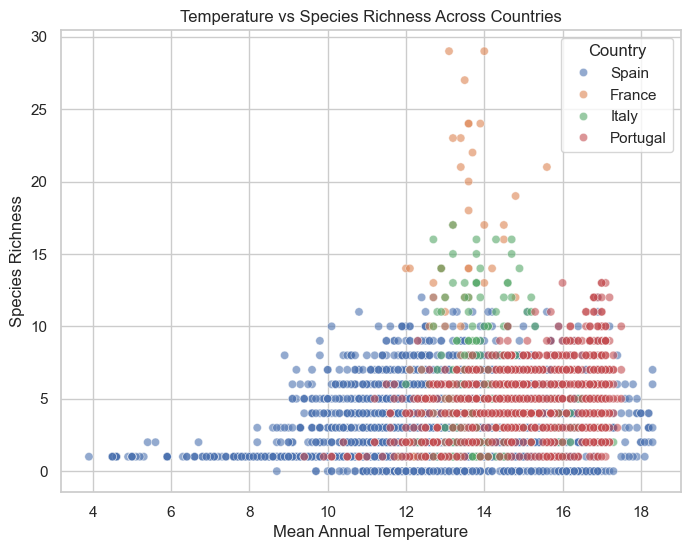

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="temp_ann",
    y="richness",
    hue="Country",
    alpha=0.6
)

plt.xlabel("Mean Annual Temperature")
plt.ylabel("Species Richness")
plt.title("Temperature vs Species Richness Across Countries")

plt.legend(title="Country")
plt.show()

### Relationship Between Temperature and Richness Across Countries

The relationship between mean annual temperature and species richness was explored across four countries: Spain, France, Italy, and Portugal.

A general positive trend can be observed in all countries, with richness tending to increase slightly with temperature. However, clear differences emerge between countries.

France shows the highest richness values and the greatest variability, with several sites exhibiting very high species richness at intermediate temperatures. Italy also presents relatively high richness values, although less extreme.

Portugal is mainly associated with higher temperature ranges but generally lower richness values, while Spain covers a broader temperature range with mostly moderate to low richness.

These differences suggest that, although temperature influences species richness, additional regional or ecological factors play an important role in shaping biodiversity patterns across countries.

## Use of AI Tools

AI tools were used to:
- Clarify concepts such as Isolation Forest
- Understand appropriate data transformations
- Support debugging of code

All analysis, interpretation, and decisions were performed independently.

# Group Members:

29211 – Aster Noel Dsouza

29400 – David Heleno Bebiano da Costa Morais 